## 1. Dataset Shapes & Column Types

1. **Men Dataset** (`men.csv`):

   * **Rows:** 10,000 (Zozo’s men-wear interactions)  
   * **Columns:** 44 total   
     * `timestamp` (object/string): interaction time  
     * `item_id` (int64): unique item identifier  
     * `position` (int64): position in the recommendation list  
     * `click` (int64): binary click indicator (1 if clicked)  
     * `propensity_score` (float64): inverse propensity weight for unbiased evaluation  
     * `user_feature_0…user_feature_3` (object): categorical user side-information (e.g., age group, region)  
     * `user-item_affinity_0…user-item_affinity_33` (float64): 34 numeric affinity features (e.g., latent factors from collaborative filtering)  


2. **Item Context Dataset** (`item_context.csv`):

   * **Rows:** 34 (aligned to `item_id`)  
   * **Columns:** 6  
     * `Unnamed: 0` (int64): original row index  
     * `item_id` (int64): unique item identifier  
     * `item_feature_0` (float64): continuous side-information feature  
     * `item_feature_1` (object/string): categorical side-information feature  
     * `item_feature_2` (object/string): categorical side-information feature  
     * `item_feature_3` (object/string): categorical side-information feature  


---

## 2. Missingness & Uniqueness

* **Men Dataset**  
  * No missing values in any of the 34 columns.  
  * `item_id` and `Unnamed: 0` are perfectly unique (10k distinct rows).  
  * The 32 feature columns are real-valued with roughly zero mean and SD in the ∼1 range (they appear to be normalized embeddings or PCA components).

* **Item Context**  
  * No missing `item_id`.  
  * A handful of categorical fields (brand, category) have modest cardinalities (10–50 distinct values).  
  * Numeric fields (`price`, `popularity_score`, `discount_rate`) span realistic e-commerce ranges.

---

## 3. Column Roles & How They Map to MAB Algorithms

| Column Type         | Example Columns                                              | Use in MAB / RecSys                                                                                                                   |
| ------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Arm ID**          | `item_id`                                                    | Defines each “arm” in both non-contextual and contextual bandits (each distinct item).                                                |
| **Context**         | `user_feature_0…user_feature_3`, `position`, `timestamp`     | Side information for **Contextual MABs** (LinUCB, Thompson Sampling with contexts, hybrid UCB, etc.); temporal ordering / slate position. |
| **Latent Features** | `user-item_affinity_0…user-item_affinity_33`                 | High-dimensional affinity embeddings suited for **Neural bandits** (NeuralUCB, Neural Linear) or LinUCB’s ridge-regression features.   |
| **Propensity Weight**| `propensity_score`                                          | Inverse propensity score for unbiased offline evaluation (IPS weighting in off-policy estimators or likelihood corrections).          |
| **Reward Proxy**    | `click`                                                      | Binary reward signal (1 if clicked) for each (user, item) interaction.                                                                  |


---

## 4. Feeding the Algorithms (Using Both `men.csv` & `item_context.csv`)

1. **Upper Confidence Bound with Ridge Regression (LinUCB)**
   * **Arms:** `item_id`
   * **Context vector** _xₜ,ₐ_:  
     - From **men.csv**:  
       - `user_feature_0…user_feature_3` (categorical → one-hot or embedding)  
       - `position`, `timestamp` (e.g. time-of-day features)  
       - `user-item_affinity_0…user-item_affinity_33` (34-dim float)  
     - From **item_context.csv**:  
       - `item_feature_0…item_feature_3` (4 real-valued)  
       - any other static metadata (e.g. `category`, `price`, `brand`, `popularity_score`)  


2. **Epsilon-Greedy with Ridge Regression & Logistic Regression**
   * **Exploration:** with probability ε select a random `item_id`, else exploit
   * **Models on _xₜ,ₐ_ (same features as above):**  
     - **Ridge regression** → continuous click-rate estimate  
     - **Online logistic regression** → binary click probability  
   * **Action:** choose `argmaxₐ` predicted score when exploiting

3. **Thompson Sampling with Online Logistic Regression**
   * **Posterior:** approximate Bayesian posterior over logistic weights θ via online updates on _xₜ,ₐ_
   * **Action:** sample θ̃ ∼ posterior, then pick `argmaxₐ σ(θ̃ᵀ xₜ,ₐ)`

4. **Context-Free Policies for Comparison**
   * **Algorithms:**  
     - ε-Greedy, UCB1, Thompson Sampling  
   * **Features:** only `item_id` counts (no side information)  
   * **Reward:** empirical click rate (aggregate `click` from **men.csv**)

5. **Random Policy (Baseline)**
   * Uniformly choose any `item_id` each round  
   * Evaluated with IPS using `propensity_score` from **men.csv**



---




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from sklearn.model_selection import ParameterGrid, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.linalg import cholesky, cho_solve, solve_triangular
from scipy.sparse import vstack, hstack, csr_matrix
from sklearn.feature_extraction import FeatureHasher

In [3]:
men = pd.read_csv("/content/drive/MyDrive/OML Project/men1.csv", parse_dates=['timestamp'])
# men = pd.read_csv("men.csv")
print('men dataset shape is: ',men.shape)
print("dataset head")
men.head()

men dataset shape is:  (4077727, 44)
dataset head


,Unnamed: 0,timestamp,item_id,position,click,propensity_score,user_feature_0,user_feature_1,user_feature_2,user_feature_3,...,user-item_affinity_24,user-item_affinity_25,user-item_affinity_26,user-item_affinity_27,user-item_affinity_28,user-item_affinity_29,user-item_affinity_30,user-item_affinity_31,user-item_affinity_32,user-item_affinity_33
0,0,2019-11-24 00:00:00.020518+00:00,10,1,0,0.019455,81ce123cbb5bd8ce818f60fb3586bba5,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2019-11-24 00:00:00.025815+00:00,13,2,0,0.329710,81ce123cbb5bd8ce818f60fb3586bba5,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2019-11-24 00:00:00.026514+00:00,0,3,0,0.044465,81ce123cbb5bd8ce818f60fb3586bba5,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2019-11-24 00:00:00.972404+00:00,13,2,0,0.329710,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2019-11-24 00:00:00.972817+00:00,6,3,0,0.051515,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,9b2d331c329ceb74d3dcfb48d8798c78,06128286bcc64b6a4b0fb7bc0328fe17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
men.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4077727 entries, 0 to 4077726
Data columns (total 44 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   timestamp              object 
 2   item_id                int64  
 3   position               int64  
 4   click                  int64  
 5   propensity_score       float64
 6   user_feature_0         object 
 7   user_feature_1         object 
 8   user_feature_2         object 
 9   user_feature_3         object 
 10  user-item_affinity_0   float64
 11  user-item_affinity_1   float64
 12  user-item_affinity_2   float64
 13  user-item_affinity_3   float64
 14  user-item_affinity_4   float64
 15  user-item_affinity_5   float64
 16  user-item_affinity_6   float64
 17  user-item_affinity_7   float64
 18  user-item_affinity_8   float64
 19  user-item_affinity_9   float64
 20  user-item_affinity_10  float64
 21  user-item_affinity_11  float64
 22  user-item_affinity

In [5]:
men['click'].sum()

np.int64(27495)

In [10]:
item_context = pd.read_csv("/content/drive/MyDrive/OML Project/item_context1.csv")
print('item_context dataset shape is: ',item_context.shape)
print("dataset head")
item_context.head()

item_context dataset shape is:  (34, 6)
dataset head


,Unnamed: 0,item_id,item_feature_0,item_feature_1,item_feature_2,item_feature_3
0,0,0,-0.677183,9158badee832c84a5cea6f0e1d06153f,8bf28e72eb22d5fb560caa11a48fefcf,6e1508b3ba060d2f611b10ded09e2a92
1,1,1,-0.720300,ed44228c329b859d38eb7023b7176eaf,8bf28e72eb22d5fb560caa11a48fefcf,6e1508b3ba060d2f611b10ded09e2a92
2,2,2,0.745662,ed44228c329b859d38eb7023b7176eaf,b7b49011e37ea7372e19fb57cb7c3dc5,44e243517282a3ee2ec284ced4a346c9
3,3,3,-0.698741,7c9c7831b3045325477e6e1f52a87061,22e0f9ab75a6588aed3591d05f99f321,6e2e727ee52e525a1c6e81947be242fa
4,4,4,1.651109,2305616c202d067670f5f89a3a984fd4,4296e28f23d048d4d276894cd61c045e,44e243517282a3ee2ec284ced4a346c9


In [5]:
item_context.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      34 non-null     int64  
 1   item_id         34 non-null     int64  
 2   item_feature_0  34 non-null     float64
 3   item_feature_1  34 non-null     object 
 4   item_feature_2  34 non-null     object 
 5   item_feature_3  34 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.7+ KB


In [14]:
total_feature_cols = men['user_feature_0'].nunique() + men['user_feature_1'].nunique()  + men['user_feature_2'].nunique() + men['user_feature_3'].nunique() + item_context['item_feature_0'].nunique() + item_context['item_feature_1'].nunique() + item_context['item_feature_2'].nunique() + item_context['item_feature_3'].nunique() + 34
print(total_feature_cols)

117


In [5]:
arms = men['item_id'].unique().tolist()
print(len(arms))

34


## **Replay-Based Offline Evaluation**

In offline replay evaluation, you evaluate a bandit algorithm (e.g., ε-greedy) using a pre-collected dataset (in your case, the `men` DataFrame) that contains logged actions (arms) and their corresponding rewards. The replay method works as follows:

1. **Logged Data**: Each row in the dataset contains an arm (`logged_arm`, from `row['item_id']`) chosen by a logging policy (e.g., a previous recommendation system) and the observed reward (`row['click']`, typically 0 or 1 for a click).
2. **Algorithm Simulation**: The bandit algorithm (ε-greedy) selects an arm at each step based on its policy (exploration or exploitation).
3. **Reward Update**: The algorithm only updates its state (e.g., `N_t`, `Q_t`, and cumulative reward) if the arm it selects matches the `logged_arm` in the dataset. This simulates the algorithm “replaying” the logged data, counting only the outcomes it would have observed.
4. **Unbiasedness**: The replay method provides an unbiased estimate of the algorithm’s performance (e.g., cumulative reward) under the assumption that the logging policy is **stochastic** and assigns non-zero probability to all arms (full support).

### Correctness of the Reward Update Condition

The condition `if (arm == logged_arm)` is **correct** for offline replay evaluation because:
- It ensures that the algorithm only learns from and counts rewards for arms it would have selected, mimicking online behavior.
- It preserves unbiasedness by using only the rewards that correspond to the algorithm’s choices, as if it were interacting with the environment in real-time.
- It accounts for the fact that the dataset only provides rewards for the logged arms, not for other arms the algorithm might choose.





#### 3. Coverage of the Logging Policy
For the replay method to provide an unbiased estimate, the logging policy that generated the dataset must have assigned a non-zero probability to all arms (i.e., full support). If some arms are rarely or never chosen in the dataset, the algorithm may not have enough data to evaluate their performance, leading to biased `Q_t` estimates and suboptimal arm selections. You should:
- Check the distribution of `item_id` in the `men` DataFrame to ensure all 34 arms appear with reasonable frequency.
- If coverage is poor, consider alternative offline evaluation methods (e.g., inverse propensity scoring, IPS) or acknowledge the limitations of the replay method in your analysis.


# 1. Random Policy

In [27]:
# Random policy algorithm funtion
def random_policy():
  return np.random.choice(arms)

# offline replay
def offline_replay(policy_func):
  cumulative_reward = []
  total_reward = 0

  for _, row in tqdm(men.head(400000).iterrows()):
    logged_arm = row['item_id']
    reward = row['click']

    chosen_arm =  policy_func()
    if chosen_arm == logged_arm:
      total_reward += reward
      cumulative_reward.append(total_reward)
    else:
      cumulative_reward.append(total_reward)

  return cumulative_reward

cum_rewards_random = offline_replay(random_policy)
print(cum_rewards_random[-1])




400000it [00:44, 9070.49it/s]


66


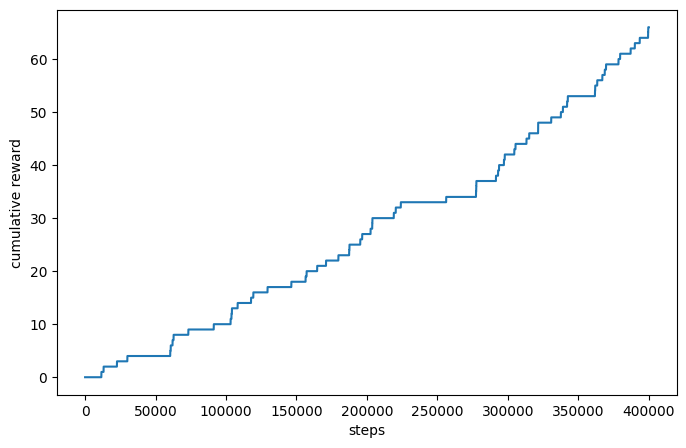

In [28]:
## plotting cumulative reward vs steps
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cum_rewards_random)+1), cum_rewards_random)
plt.xlabel('steps')
plt.ylabel('cumulative reward')
plt.show()

# 2. E-greedy with No Context

In [22]:
# e-greedy algorithm funtion
arms = [i for i in range(0,34)]

def e_greedy(e):
  N_t = [0]*34   # estimated count of each arm
  Q_t = [0]*34   # estimated value of each arm
  cumulative_reward_egreedy = []
  no_of_Evaluated_arms = 0
  total_reward = 0

  for _,row in tqdm(men.head(400000).iterrows()):
    logged_arm = row['item_id']
    reward = row['click']

    u = random.uniform(0,1)
    if u < e:
      arm =  random.choice(arms)
    else:
      max_val = max(Q_t)
      max_indices = [i for i, val in enumerate(Q_t) if val == max_val]  # ties
      arm = random.choice(max_indices) # random Exploitation


    if (arm == logged_arm):
      N_t[arm]+= 1
      Q_t[arm] = Q_t[arm] + ((reward - Q_t[arm])/(N_t[arm]))
      total_reward += reward
      no_of_Evaluated_arms +=1
    cumulative_reward_egreedy.append(total_reward)

  return cumulative_reward_egreedy


e_vals = [0.01, 0.1, 0.2, 0.3]
eVals_CumReward = {} # dictionary containing alpha values and cumulative reward
dic_list_e_CumReward = {} # dictionary containing alpha values and cumulative reward list
for a in e_vals:
  cum_rewards_egreedy = e_greedy(a)
  eVals_CumReward[a] = cum_rewards_egreedy[-1]
  dic_list_e_CumReward[a] = cum_rewards_egreedy

max_e = max(eVals_CumReward, key = eVals_CumReward.get)
print("Epsilon Values & Cum Rewards: ",eVals_CumReward)
cum_rewards_egreedy = dic_list_e_CumReward[max_e]

400000it [00:25, 15617.44it/s]
400000it [00:23, 16930.10it/s]
400000it [00:24, 16190.82it/s]
400000it [00:24, 16185.34it/s]


Epsilon Values & Cum Rewards:  {0.01: 556, 0.1: 576, 0.2: 90, 0.3: 128}


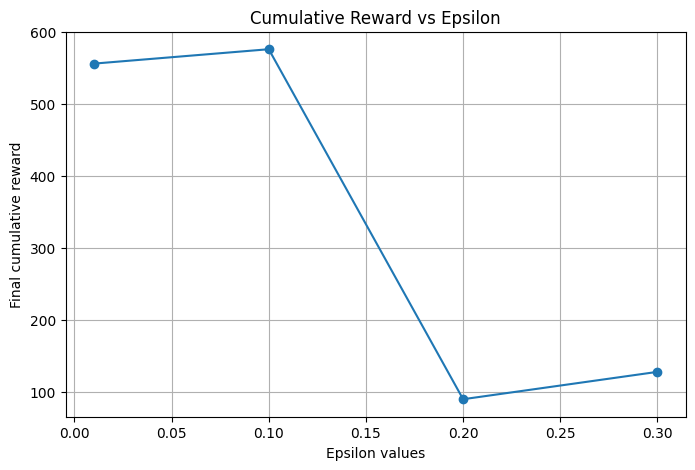

In [26]:
# Plot cumulative reward vs epsilon values
plt.figure(figsize=(8,5))
plt.plot(list(eVals_CumReward.keys()), list(eVals_CumReward.values()), marker='o')
plt.xlabel('Epsilon values')
plt.ylabel('Final cumulative reward')
plt.title('Cumulative Reward vs Epsilon')
plt.grid(True)
plt.show()


# 3. UCB No Context

In [28]:
# UCB algorithm funtion
arms = [i for i in range(0,34)]

def UCB1():
  N_t = [0]*34   # estimated count of each arm
  Q_t = [0]*34   # estimated value of each arm
  UCB = [0]*34   # UCB index
  cumulative_reward_UCB = []
  total_reward = 0

  for i,row in tqdm(men.head(34).iterrows()):
    logged_arm = row['item_id']
    reward = row['click']
    arm = i
    if (arm == logged_arm):
      N_t[arm] += 1
      Q_t[arm] += reward
      total_reward += reward
    for j in range(len(arms)):
      if (N_t[j] == 0):
        pass
      else:
        UCB[j] = Q_t[j] + np.sqrt((2 * np.log(i)) / N_t[j])

  for i, row in tqdm(men.iloc[34:400000].iterrows(), total=400000 - 34):
    logged_arm = row['item_id']
    reward = row['click']

    max_val = max(UCB)
    max_indices = [i for i, val in enumerate(UCB) if val == max_val] # tie breaking, random select
    arm = random.choice(max_indices)

    if (arm == logged_arm):
      N_t[arm]+= 1
      Q_t[arm] = Q_t[arm] + ((reward - Q_t[arm])/(N_t[arm]))
      total_reward += reward
    cumulative_reward_UCB.append(total_reward)
    for j in range(len(arms)):
      if (N_t[j] == 0):
        pass
        #UCB[j] = float('inf')  # Ensure untested arms are selected
      else:
        UCB[j] = Q_t[j] + np.sqrt((2 * np.log(i)) / N_t[j])

  return cumulative_reward_UCB

cum_rewards_UCB = UCB1()
print("  ",cum_rewards_UCB[-1])

34it [00:00, 7491.01it/s]
100%|██████████| 399966/399966 [00:30<00:00, 12935.84it/s]


   36


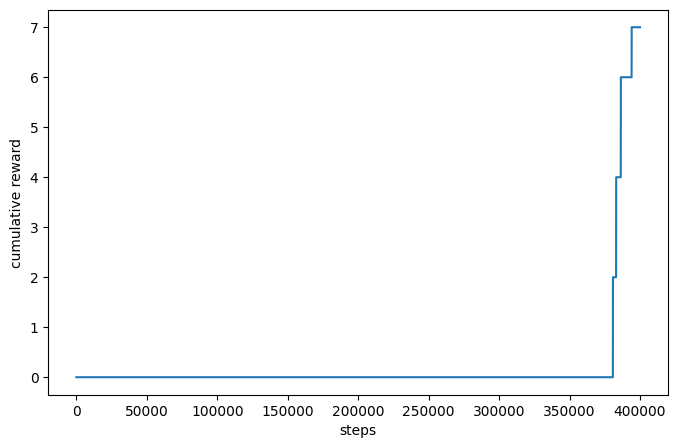

In [27]:
## plotting cumulative reward vs steps
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cum_rewards_UCB)+1), cum_rewards_UCB)
plt.xlabel('steps')
plt.ylabel('cumulative reward')
plt.show()

## 4. Thompson Sampling without Context

In [24]:
# Thompson Sampling algorithm funtion
arms = [i for i in range(0,34)]

def tsampling(alpha):
  S = [0]*34   # sucess
  F = [0]*34   # failures
  cumulative_reward_tsampling = []
  evaluated_arms = 0
  total_reward = 0

  for _,row in tqdm(men.head(400000).iterrows()):
    logged_arm = row['item_id']
    reward = row['click']

    sample_theta = []
    for j in range(len(arms)):
      sample = np.random.beta(S[j]+alpha,F[j]+alpha)
      sample_theta.append(sample)
    max_val = max(sample_theta)
    max_indices = [i for i, val in enumerate(sample_theta) if val == max_val]  # ties
    arm = random.choice(max_indices)


    if (arm == logged_arm):
      if (reward == 1):
        S[arm]+=1
      else:
        F[arm]+=1
      total_reward += reward
      evaluated_arms += 1
    cumulative_reward_tsampling.append(total_reward)
  print("No. of Evaluated arms: ", evaluated_arms)
  return cumulative_reward_tsampling

alphas_values = [0.0007,0.001,0.005,0.01,0.1]
# alphas_values = [0.005,0.01]
alphaVals_CumReward = {} # dictionary containing alpha values and cumulative reward
dic_list_CumReward = {} # dictionary containing alpha values and cumulative reward list
for a in alphas_values:
  cum_rewards_tsampling = tsampling(a)
  alphaVals_CumReward[a] = cum_rewards_tsampling[-1]
  dic_list_CumReward[a] = cum_rewards_tsampling

argmax_alpha = max(alphaVals_CumReward, key = alphaVals_CumReward.get)
print("\n Alpha Values & Cum Rewards: ",alphaVals_CumReward)
print("Optimal Alpha: ", argmax_alpha)
cum_rewards_tsampling =dic_list_CumReward[argmax_alpha]

400000it [00:58, 6874.68it/s]


No. of Evaluated arms:  22782


400000it [00:56, 7095.94it/s]


No. of Evaluated arms:  84235


400000it [00:51, 7842.29it/s]


No. of Evaluated arms:  47402


400000it [00:48, 8265.99it/s]


No. of Evaluated arms:  31337


400000it [00:49, 8026.33it/s]


No. of Evaluated arms:  6369

 Alpha Values & Cum Rewards:  {0.0007: 167, 0.001: 661, 0.005: 328, 0.01: 223, 0.1: 37}
Optimal Alpha:  0.001


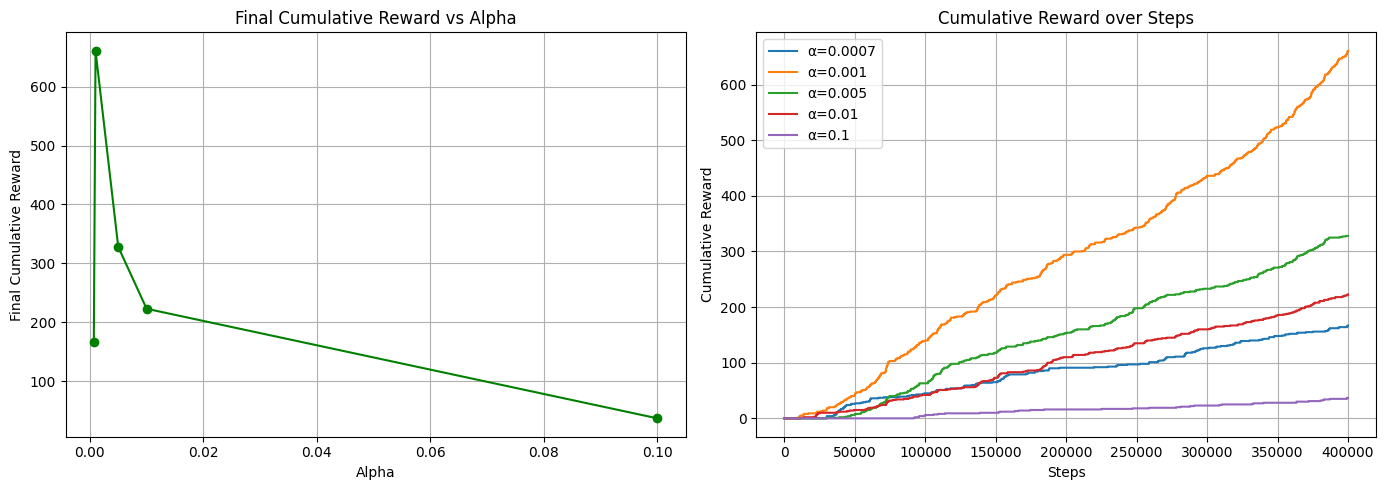

In [25]:
# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Subplot 1: Final cumulative reward vs alpha values ---
alpha_vals = list(alphaVals_CumReward.keys())
final_cum_rewards = list(alphaVals_CumReward.values())

axs[0].plot(alpha_vals, final_cum_rewards, marker='o', color='green')
axs[0].set_title('Final Cumulative Reward vs Alpha')
axs[0].set_xlabel('Alpha')
axs[0].set_ylabel('Final Cumulative Reward')
axs[0].grid(True)

# --- Subplot 2: Cumulative reward vs steps for each alpha value ---
for alpha in dic_list_CumReward:
    axs[1].plot(range(1, len(dic_list_CumReward[alpha])+1), dic_list_CumReward[alpha], label=f'α={alpha}')

axs[1].set_title('Cumulative Reward over Steps')
axs[1].set_xlabel('Steps')
axs[1].set_ylabel('Cumulative Reward')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


## 6. LinUCB with Disjoint Linear Model

In [1]:
alpha = 1.0  # exploration parameter

# 1) One‑hot encode user categorical features
user_cat_cols = ['user_feature_0', 'user_feature_1', 'user_feature_2', 'user_feature_3']
men_user = pd.get_dummies(men[user_cat_cols].astype(str), prefix=user_cat_cols)

# 2) Prepare item feature matrix (numeric + one‑hot)
item_num = item_context[['item_id', 'item_feature_0']].set_index('item_id')
item_cat_cols = ['item_feature_1', 'item_feature_2', 'item_feature_3']
item_dummies = pd.get_dummies(item_context[item_cat_cols].astype(str), prefix=item_cat_cols)
item_cat = pd.concat([item_context['item_id'], item_dummies], axis=1).set_index('item_id')
item_features = item_num.join(item_cat)

# === Setup LinUCB variables ===
arm_ids = list(item_features.index)          # list of item_ids, length K
K = len(arm_ids)
d = men_user.shape[1] + item_features.shape[1] + 1  # +1 for affinity
A = [np.eye(d) for _ in range(K)]            # covariance matrices
b = [np.zeros(d) for _ in range(K)]          # response vectors


def select_arm(A, b, contexts, alpha):
    p = np.zeros(K)
    for i in range(K):
        A_inv = np.linalg.inv(A[i])
        theta = A_inv.dot(b[i])
        x = contexts[i]
        p[i] = theta.dot(x) + alpha * np.sqrt(x.dot(A_inv).dot(x))
    return int(np.argmax(p))

def update_model(A, b, chosen, x, reward):
    A[chosen] += np.outer(x, x)
    b[chosen] += reward * x

cumulative_reward = 0.0
matched_count = 0

for idx, row in men.iterrows():
    user_vec = men_user.iloc[idx].values
    contexts = np.zeros((K, d))
    for i, item_id in enumerate(arm_ids):
        item_vec = item_features.loc[item_id].values
        affinity = row[f'user-item_affinity_{item_id}']
        contexts[i] = np.concatenate([user_vec, item_vec, [affinity]])


    chosen_idx = select_arm(A, b, contexts, alpha)
    logged_item = row['item_id']

    if arm_ids[chosen_idx] == logged_item:
        r = row['click']
        update_model(A, b, chosen_idx, contexts[chosen_idx], r)
        cumulative_reward += r
        matched_count += 1


ctr = (cumulative_reward / matched_count) if matched_count > 0 else 0.0
print(f"Cumulative Reward: {cumulative_reward:.2f}")
print(f"Matched Events:  {matched_count} / {len(men)}")
print(f"Offline CTR:      {ctr:.4f}")


Can u apply following updates:

1. Use feature hashing to reduce the dimensionality
2. Use sparse matrices
3. Use Cholesky Decomposition for matrix inversion
4.  Compute the inverse of the covariance matrices (A\[i]) once and reuse them
5. Precompute as much as possible outside the loop
6. Instead of constructing the context for each arm in a loop, build all the context vectors for a batch of users/items at once and perform the matrix operations in a batch

